In [5]:
# Nifty Options Position Sizing — corrected
capital       = 1000000      # your trading capital in ₹
risk_pct      = 1          # risk % per trade
premium       = 150         # option premium (current market price)
lot_size      = 75          # units per lot — check your broker
desired_lots  = 2           # how many lots you want to trade
sl_pct        = 50          # stop loss as % of premium

# ── calculations ──────────────────────────────
max_risk      = capital * risk_pct / 100
cost_per_lot  = premium * lot_size
max_lots      = int(max_risk / cost_per_lot)

# quantity = lots × lot_size (what you actually buy)
qty_max       = max_lots * lot_size
qty_desired   = desired_lots * lot_size

sl_price      = premium * (1 - sl_pct / 100)
loss_per_lot  = (premium - sl_price) * lot_size
total_loss    = loss_per_lot * desired_lots

target_prem   = premium + (premium - sl_price) * 2   # 1:2 RR
profit_if_hit = (target_prem - premium) * lot_size * desired_lots

# ── output ────────────────────────────────────
print(f"Capital:            ₹{capital:,.0f}")
print(f"Max risk per trade: ₹{max_risk:,.0f}")
print(f"Cost per lot:       ₹{cost_per_lot:,.0f}")
print(f"Max lots allowed:   {max_lots} lots ({qty_max} units)")
print(f"\nYou want {desired_lots} lots → {qty_desired} units")

if desired_lots > max_lots:
    print(f"⚠  EXCEEDS RISK LIMIT — max is {max_lots} lot(s)")
else:
    print(f"✓  Within risk limit")

print(f"\nEntry premium:      ₹{premium}")
print(f"Stop loss at:       ₹{sl_price:.1f}  (lose ₹{total_loss:,.0f} total)")
print(f"Target at:          ₹{target_prem:.1f}  (gain ₹{profit_if_hit:,.0f} total)")
print(f"Total outlay:       ₹{cost_per_lot * desired_lots:,.0f}")

Capital:            ₹1,000,000
Max risk per trade: ₹10,000
Cost per lot:       ₹11,250
Max lots allowed:   0 lots (0 units)

You want 2 lots → 150 units
⚠  EXCEEDS RISK LIMIT — max is 0 lot(s)

Entry premium:      ₹150
Stop loss at:       ₹75.0  (lose ₹11,250 total)
Target at:          ₹300.0  (gain ₹22,500 total)
Total outlay:       ₹22,500


In [6]:
import yfinance as yf
import pandas as pd

# Download Nifty 50 data — last 6 months
nifty = yf.download("^NSEI", period="6mo", interval="1d")

print(nifty.tail(10))          # last 10 rows
print(nifty.shape)             # how many rows/columns
print(nifty.describe())        # statistics

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2026-03-16  23408.800781  23502.000000  22955.250000  23116.099609  540300
2026-03-17  23581.150391  23656.800781  23346.599609  23493.199219  458800
2026-03-18  23777.800781  23862.250000  23618.449219  23632.900391  382900
2026-03-19  23002.150391  23378.699219  22930.349609  23197.750000  550100
2026-03-20  23114.500000  23345.150391  23067.599609  23110.150391  663300
2026-03-23  22512.650391  22851.699219  22471.250000  22824.349609  550300
2026-03-24  22912.400391  23057.300781  22624.199219  22878.449219  538100
2026-03-25  23306.449219  23465.349609  23063.199219  23064.400391  505400
2026-03-27  22819.599609  23186.099609  22804.550781  23173.550781  612600
2026-03-30  22370.800781  22714.099609  22283.849609  22549.650391       0
(122, 5)
Price          C

In [7]:
nifty['Daily_Return'] = nifty['Close'].pct_change() * 100

print(nifty[['Close', 'Daily_Return']].tail(20))
print(f"\nAverage daily return: {nifty['Daily_Return'].mean():.3f}%")
print(f"Best day: {nifty['Daily_Return'].max():.2f}%")
print(f"Worst day: {nifty['Daily_Return'].min():.2f}%")
print(f"Volatility (std): {nifty['Daily_Return'].std():.3f}%")

Price              Close Daily_Return
Ticker             ^NSEI             
Date                                 
2026-02-27  25178.650391    -1.246837
2026-03-02  24865.699219    -1.242923
2026-03-04  24480.500000    -1.549119
2026-03-05  24765.900391     1.165827
2026-03-06  24450.449219    -1.273732
2026-03-09  24028.050781    -1.727569
2026-03-10  24261.599609     0.971984
2026-03-11  23866.849609    -1.627057
2026-03-12  23639.150391    -0.954040
2026-03-13  23151.099609    -2.064587
2026-03-16  23408.800781     1.113127
2026-03-17  23581.150391     0.736260
2026-03-18  23777.800781     0.833930
2026-03-19  23002.150391    -3.262078
2026-03-20  23114.500000     0.488431
2026-03-23  22512.650391    -2.603775
2026-03-24  22912.400391     1.775668
2026-03-25  23306.449219     1.719806
2026-03-27  22819.599609    -2.088905
2026-03-30  22370.800781    -1.966725

Average daily return: -0.075%
Best day: 2.55%
Worst day: -3.26%
Volatility (std): 0.869%


Matplotlib is building the font cache; this may take a moment.


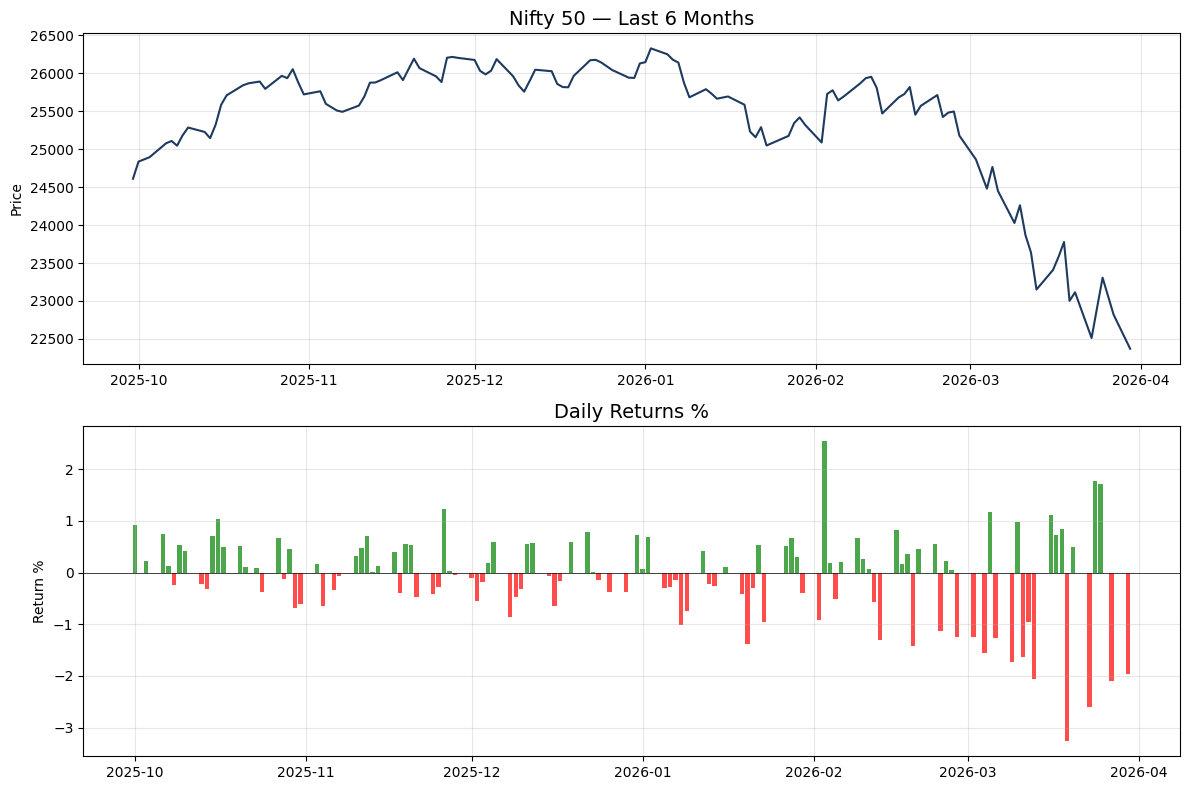

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Chart 1: Nifty price
ax1.plot(nifty['Close'], color='#1E3A5F', linewidth=1.5)
ax1.set_title('Nifty 50 — Last 6 Months', fontsize=14)
ax1.set_ylabel('Price')
ax1.grid(True, alpha=0.3)

# Chart 2: Daily returns
colors = ['green' if x >= 0 else 'red' 
          for x in nifty['Daily_Return'].dropna()]
ax2.bar(nifty['Daily_Return'].dropna().index, 
        nifty['Daily_Return'].dropna(), 
        color=colors, alpha=0.7)
ax2.set_title('Daily Returns %', fontsize=14)
ax2.set_ylabel('Return %')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nifty_analysis.png')
plt.show()